In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress
import itertools as it
from matplotlib import rcParams
import matplotlib.colors as mcolors
from utils.analysis import uq_get_obs, uq_get_sim

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_default = '20231116'
#prefix_uptake = '20240401'
prefix_list = [prefix_default] #, prefix_uptake] # , '20240316_2']

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

In [2]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list_uq = ['UQ_20231118', 'UQ_20240107', 'UQ_20240112'] # , 'UQ_20240312_test20241017']
N_list = [4000, 4000, 4000]
BLOCK_LIST = [200, 200, 200]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE']

collection_obs = uq_get_obs(VAR_LIST)

collection_sim = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list_uq):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(
            os.environ['PROJDIR'], 'ELM_Phenology', 'output', "extract", prefix,
            f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)

    collection_sim[prefix] = collect

collection_sim_target = {}
for prefix in prefix_list:
    collection_sim_target[prefix] = uq_get_sim(prefix, VAR_LIST)

/autofs/nccsopen-svm1_home/ywo/Git/phenology_elm/utils/analysis.py:1160: PerformanceWarning: indexing past lexsort depth may impact performance.
  sim_tair = sim_data.loc['average', 'Tair']


In [3]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']
sub1 = np.arange(10)
sub2 = np.arange(10,14)
xticklabels = {
    0: [var.replace('_','$_{')+'}$'+f' {co2}' for var in VAR_SUBSET[:5] \
        for co2 in ['', 'CO2']],
    1: [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET[5:] \
        for co2 in ['', 'CO2']],
}
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

# (note: the index values is ensemble_id minus one, because Python index starts
#  from 0, and ensemble id starts from 1)
n_best_ind = 40
best_ind = {'UQ_20231118': 3066, 'UQ_20240107': 1484, 'UQ_20240112': 1943}
#best_ind = {'UQ_20231118': 1180, 'UQ_20240107': 1740, 'UQ_20240112': 1943}

obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_mean_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 1].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
obs_slope_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 3].reshape(1,-1)
sims_target_mean = {}
sims_target_slope = {}
for prefix in collection_sim_target:
    sims_target_mean[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 0].reshape(1, -1)
    sims_target_slope[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 2].reshape(1, -1)


labs = 'abcd'
clist = ['#1b249e', '#05dbfc', '#ffa500', '#ff0000'] # '#1a80bb'

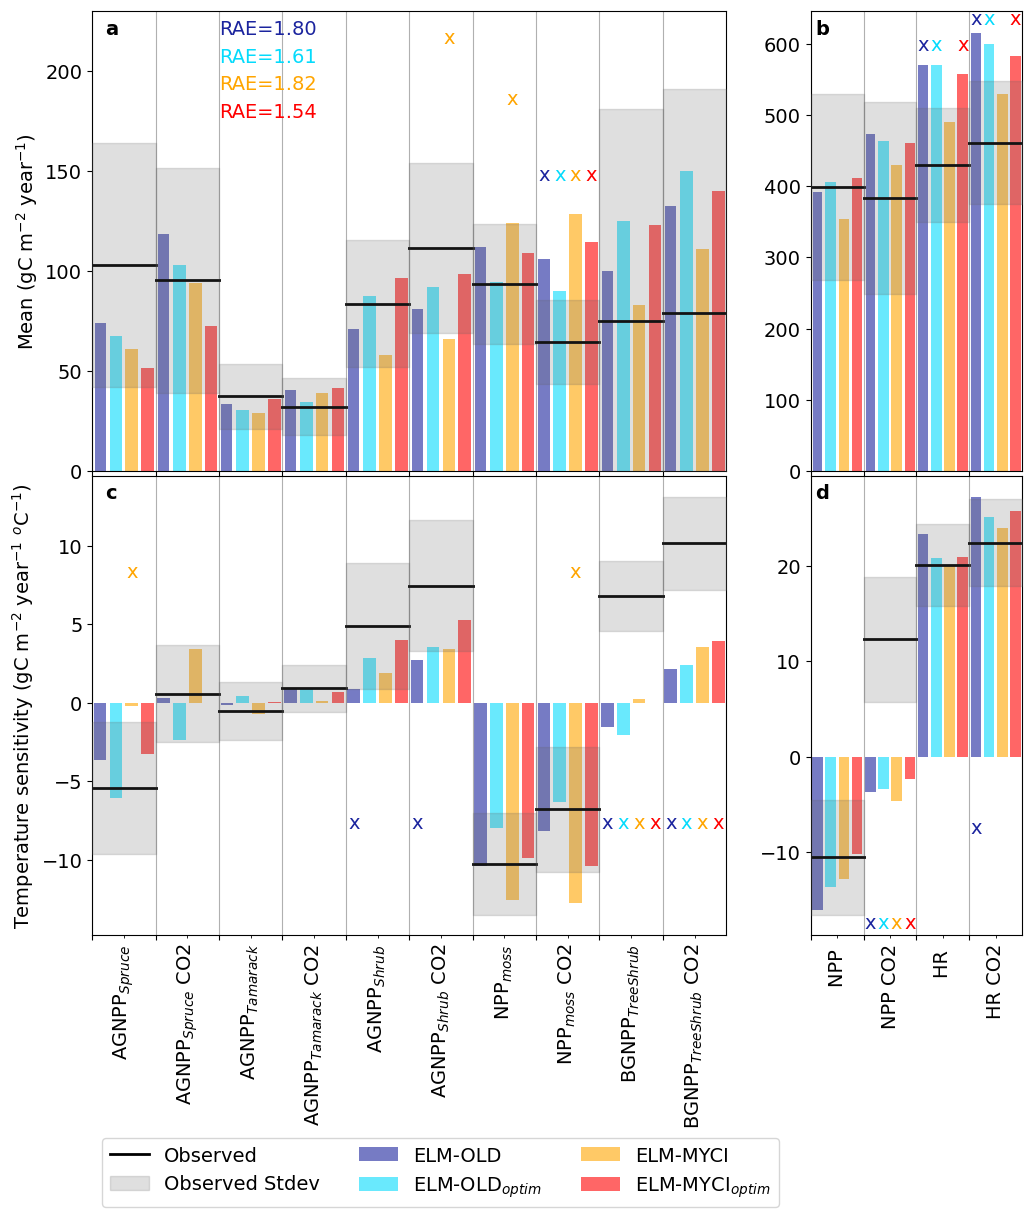

In [4]:
# Do I want to display the best performing 40 members envelops? No. 
show_sim_uncertainty = False


fig, axes = plt.subplots(2, 2, figsize = (12, 12), # sharex = True, 
                         gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(hspace = 0.01)
for s, sub in enumerate([sub1, sub2]):
    ax = axes.flat[s]
    for j in range(len(sub)):
        c = np.mod(j, 2) # 0 = ACO2, 1 = ECO2

        x1 = (len(prefix_list_uq)+1)*j
        x2 = x1 + len(prefix_list_uq) + 1

        h1 = ax.plot([x1,x2], 2*[obs_mean[0, sub][j]],
                     color = 'k', lw = 2, zorder = 3) # ['#636363', '#a8a8a8'] * len(sub)
        he = ax.fill_between(
            [x1, x2], 
            2*[obs_mean[0, sub][j] - obs_mean_std[0,sub][j]], 
            2*[obs_mean[0, sub][j] + obs_mean_std[0,sub][j]],
            color = '#636363', alpha = 0.2, zorder = 3)

        if s == 0:
            #ax.set_ylabel('M$_{obs,c,v}$ or M$_{sim,c,v}$ (gC m$^{-2}$)')
            ax.set_ylabel('Mean (gC m$^{-2}$ year$^{-1}$)')

    ax = axes.flat[2+s]
    for j in range(len(sub)):
        x1 = (len(prefix_list_uq)+1)*j
        x2 = x1 + len(prefix_list_uq) + 1

        h1 = ax.plot([x1,x2], 2*[obs_slope[0, sub][j]],
                     color = 'k', lw = 2, zorder = 3) # ['#636363', '#a8a8a8'] * len(sub)
        he = ax.fill_between(
            [x1, x2], 
            2*[obs_slope[0, sub][j] - obs_slope_std[0,sub][j]], 
            2*[obs_slope[0, sub][j] + obs_slope_std[0,sub][j]],
            color = '#636363', alpha = 0.2, zorder = 3)

    if s == 0:
        #ax.set_ylabel('S$_{obs,c,v}$ or S$_{sim,c,v}$ (gC m$^{-2}$ $^o$C$^{-1}$)')
        ax.set_ylabel('Temperature sensitivity (gC m$^{-2}$ year$^{-1}$ $^o$C$^{-1}$)')

h2 = [None] * len(prefix_list_uq)
h3 = [None] * len(prefix_list_uq)
h4 = [None] * 2


# save whether within the std of observation
within_obs_std = {}

for p, prefix in enumerate(prefix_list):

    # find the best runs
    rmse_weights = np.repeat(np.array([1, 1, 1, 1, 1, 1, 1]), 2).reshape(1,-1)
    rmse_mean = np.mean((np.abs(sims_target_mean[prefix] - obs_mean) / obs_mean_std)*rmse_weights, axis = 1)
    rmse_slope = np.mean((np.abs(sims_target_slope[prefix] - obs_slope) / obs_slope_std)*rmse_weights, axis = 1)
    rmse_tot = (rmse_mean + rmse_slope)[0]

    axes.flat[0].text(0.2, 0.95, f'RAE={rmse_tot:.2f}', color = clist[p], 
                      transform = axes.flat[0].transAxes, fontsize = 14, zorder =5)

    for s, sub in enumerate([sub1, sub2]):
        x_pos = np.arange(p+0.5, len(sub)*(len(prefix_list_uq)+1), len(prefix_list_uq)+1)

        ax = axes.flat[s]
        h4[p] = ax.bar(x_pos, sims_target_mean[prefix][0, sub], width = 0.7,
                       color = clist[p], alpha = 0.6)

        within_obs_std[(prefix, s, 'mean')] = \
            (sims_target_mean[prefix][0, sub] >= (obs_mean[0, sub] - obs_mean_std[0, sub])) & \
            (sims_target_mean[prefix][0, sub] <= (obs_mean[0, sub] + obs_mean_std[0, sub]))
        for x in range(len(sub)):
            x_pos_temp = x_pos[x]
            if s == 0:
                y = (obs_mean[0,sub][x] + obs_mean_std[0,sub][x]) + 60
            else:
                y = (obs_mean[0,sub][x] + obs_mean_std[0,sub][x]) + 80
            if not within_obs_std[(prefix, s, 'mean')][x]:
                ax.text(x_pos_temp, y, 'x', color = clist[p], horizontalalignment = 'center')

        ax = axes.flat[2+s]
        h4[p] = ax.bar(x_pos, sims_target_slope[prefix][0, sub], color = clist[p], 
                       alpha = 0.6)

        within_obs_std[(prefix, s, 'slope')] = \
            (sims_target_slope[prefix][0, sub] >= (obs_slope[0, sub] - obs_slope_std[0, sub])) & \
            (sims_target_slope[prefix][0, sub] <= (obs_slope[0, sub] + obs_slope_std[0, sub]))
        for x in range(len(sub)):
            x_pos_temp = x_pos[x]
            y = -0.2 * obs_slope[0, sub][x]
            y = np.sign(y) * max(np.abs(y), 8)
            if sub[x] == 11:
                y = y - 10
            if not within_obs_std[(prefix, s, 'slope')][x]:
                ax.text(x_pos_temp, y, 'x', color = clist[p], horizontalalignment = 'center')


for p, prefix in enumerate(prefix_list_uq, len(prefix_list)):

    # the 2 is ACO2 and ECO2
    sim_mean = collection_sim[prefix][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
    sim_slope = collection_sim[prefix][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

    # find the best runs
    rmse_weights = np.repeat(np.array([1, 1, 1, 1, 1, 1, 1]), 2).reshape(1,-1)
    rmse_mean = np.mean((np.abs(sim_mean - obs_mean) / obs_mean_std)*rmse_weights, axis = 1)
    rmse_slope = np.mean((np.abs(sim_slope - obs_slope) / obs_slope_std)*rmse_weights, 
                            axis = 1)
    rmse_tot = rmse_mean + rmse_slope

    best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]

    sim_mean_bi = sim_mean[best_inds, :]
    sim_slope_bi = sim_slope[best_inds, :]

    axes.flat[0].text(0.2, 0.95-p*0.06, f'RAE={rmse_tot[best_ind[prefix]]:.2f}', color = clist[p], 
                      transform = axes.flat[0].transAxes, fontsize = 14, zorder =5)

    for s, sub in enumerate([sub1, sub2]):
        x_pos = np.arange(p+len(prefix_list)-0.5, 
                          len(sub)*(len(prefix_list_uq)+1), len(prefix_list_uq)+1)

        ax = axes.flat[s]
        sim_mean_temp = sim_mean[best_ind[prefix], sub]
        # sim_mean_temp = sim_mean_bi.mean(axis = 0)[sub]
        h2[p-len(prefix_list)] = ax.bar(x_pos, sim_mean_temp, color = clist[p], alpha = 0.6)
        if show_sim_uncertainty:
            h3[p-len(prefix_list)] = ax.errorbar(x_pos, sim_mean_temp, 
                yerr = np.abs(np.vstack([np.min(sim_mean_bi, axis = 0)[sub],
                                        np.max(sim_mean_bi, axis = 0)[sub]]) - \
                            sim_mean_temp), color = 'k', lw=0, elinewidth=1,
                capsize = 2, barsabove = True)

        within_obs_std_temp = \
            (sim_mean_temp >= (obs_mean[0, sub] - obs_mean_std[0, sub])) & \
            (sim_mean_temp <= (obs_mean[0, sub] + obs_mean_std[0, sub]))
        for x in range(len(sub)):
            x_pos_temp = x_pos[x]
            if s == 0:
                y = (obs_mean[0,sub][x] + obs_mean_std[0,sub][x]) + 60
            else:
                y = (obs_mean[0,sub][x] + obs_mean_std[0,sub][x]) + 80
            #if (within_obs_std_temp[x] & ~within_obs_std[(prefix_default, s, 'mean')][x]):
            #    ax.text(x_pos_temp, y, '>', color = clist[p], horizontalalignment = 'center')
            #elif (~within_obs_std_temp[x] & within_obs_std[(prefix_default, s, 'mean')][x]):
            #    ax.text(x_pos_temp, y, '<', color = clist[p], horizontalalignment = 'center')
            #else:
            #    ax.text(x_pos_temp, y, '=', color = clist[p], horizontalalignment = 'center')
            if not within_obs_std_temp[x]:
                ax.text(x_pos_temp, y, 'x', color = clist[p], horizontalalignment = 'center')

        if s == 0:
            ax.set_ylim([0, 230])
        ax.set_xlim([0., len(sub)*(len(prefix_list_uq)+1)])
        ax.set_xticks(np.arange(0, len(sub)*(len(prefix_list_uq)+1), 
                                len(prefix_list_uq)+1))
        ax.grid(True, axis = 'x')
        ax.set_xticklabels([])

        ax = axes.flat[2+s]
        sim_slope_temp = sim_slope[best_ind[prefix], sub]
        h2[p-len(prefix_list)] = ax.bar(x_pos, sim_slope_temp, color = clist[p], alpha = 0.6)
        face_color = mcolors.to_rgba(clist[p], alpha=0.2)
        if show_sim_uncertainty:
            h3[p-len(prefix_list)] = ax.errorbar(x_pos, sim_slope_temp,
                yerr = np.abs(np.vstack([np.min(sim_slope_bi, axis = 0)[sub],
                                        np.max(sim_slope_bi, axis = 0)[sub]]) - \
                            sim_slope_temp), color = 'k', lw=0, elinewidth=1,
                capsize = 5, barsabove = True)

        within_obs_std_temp = \
            (sim_slope_temp >= (obs_slope[0, sub] - obs_slope_std[0, sub])) & \
            (sim_slope_temp <= (obs_slope[0, sub] + obs_slope_std[0, sub]))
        for x in range(len(sub)):
            x_pos_temp = x_pos[x]
            y = -0.2 * obs_slope[0, sub][x]
            y = np.sign(y) * max(np.abs(y), 8)
            if sub[x] == 11:
                y = y - 10
            #if (within_obs_std_temp[x] & ~within_obs_std[(prefix_default, s, 'slope')][x]):
            #    ax.text(x_pos_temp, y, '>', color = clist[p], horizontalalignment = 'center')
            #elif (~within_obs_std_temp[x] & within_obs_std[(prefix_default, s, 'slope')][x]):
            #    ax.text(x_pos_temp, y, '<', color = clist[p], horizontalalignment = 'center')
            #else:
            #    ax.text(x_pos_temp, y, '=', color = clist[p], horizontalalignment = 'center')
            if not within_obs_std_temp[x]:
                ax.text(x_pos_temp, y, 'x', color = clist[p], horizontalalignment = 'center')

        ax.set_xlim([0., len(sub)*(len(prefix_list_uq)+1)])
        ax.set_xticks(np.arange(0, len(sub)*(len(prefix_list_uq)+1), 
                                len(prefix_list_uq)+1), minor=False)
        ax.set_xticklabels([], minor=False)
        ax.grid(True, axis = 'x')
        ax.set_xticks(np.arange(2, len(sub)*(len(prefix_list_uq)+1), 
                                len(prefix_list_uq)+1), minor = True)
        ax.set_xticklabels(xticklabels[s], rotation = 90, minor = True)

legend_names = ['Observed', 'Observed Stdev', 'ELM-OLD', 'ELM-OLD$_{optim}$', 
                'ELM-MYCI', 'ELM-MYCI$_{optim}$']

ax = axes.flat[0]
if show_sim_uncertainty:
    ax.legend([h1[0], he] + [h4[0]] + list(zip(h2, h3)), legend_names,
            bbox_to_anchor = (0, -1.43), ncol = 3, loc = 'upper left')
else:
    ax.legend([h1[0], he] + [h4[0]] + h2, legend_names,
            bbox_to_anchor = (0, -1.43), ncol = 3, loc = 'upper left')
for i in range(4):
    axes.flat[i].text(0.02, 0.95, labs[i], fontdict = {'weight': 'bold'},
                      transform = axes.flat[i].transAxes)